# Dice Roll Simulation — Central Limit Theorem
This notebook simulates rolling different numbers of dice and plots the resulting probability distributions, demonstrating how the sum of independent random variables converges to a normal distribution as the number of dice increases.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Configuration

In [2]:
# Number of simulations — higher = smoother distribution
num_simulations = 10_000

# How many dice to roll in each experiment
dice_to_roll = [1, 4, 12]

## 3. Run Simulations

In [3]:
simulation_results = {}

print("Running simulations...")

for num_dice in dice_to_roll:
    label = f"{num_dice} {'Die' if num_dice == 1 else 'Dice'}"
    print(f"  Simulating {label}...")

    # 2D array: rows = simulations, cols = individual dice
    rolls = np.random.randint(1, 7, size=(num_simulations, num_dice))

    # Sum across columns → one total per simulation
    simulation_results[label] = rolls.sum(axis=1)

print("Done!")

Running simulations...
  Simulating 1 Die...
  Simulating 4 Dice...
  Simulating 12 Dice...
Done!


## 4. Organise Results into a DataFrame

In [4]:
df_sums = pd.DataFrame(simulation_results)

print("First 5 rows:")
display(df_sums.head())

print("\nSummary statistics:")
display(df_sums.describe().round(3))

First 5 rows:


,1 Die,4 Dice,12 Dice
0,2,14,36
1,3,18,28
2,1,20,36
3,3,17,36
4,3,17,50



Summary statistics:


,1 Die,4 Dice,12 Dice
count,10000.000,10000.000,10000.000
mean,3.473,14.042,41.926
std,1.716,3.422,5.939
min,1.000,4.000,21.000
25%,2.000,12.000,38.000
50%,3.000,14.000,42.000
75%,5.000,16.000,46.000
max,6.000,24.000,65.000


## 5. Visualise — Probability Mass Function
Each bar shows the probability of that exact sum occurring.
Notice how the distribution shifts from uniform (1 die) toward a bell curve (12 dice) — this is the **Central Limit Theorem** in action.

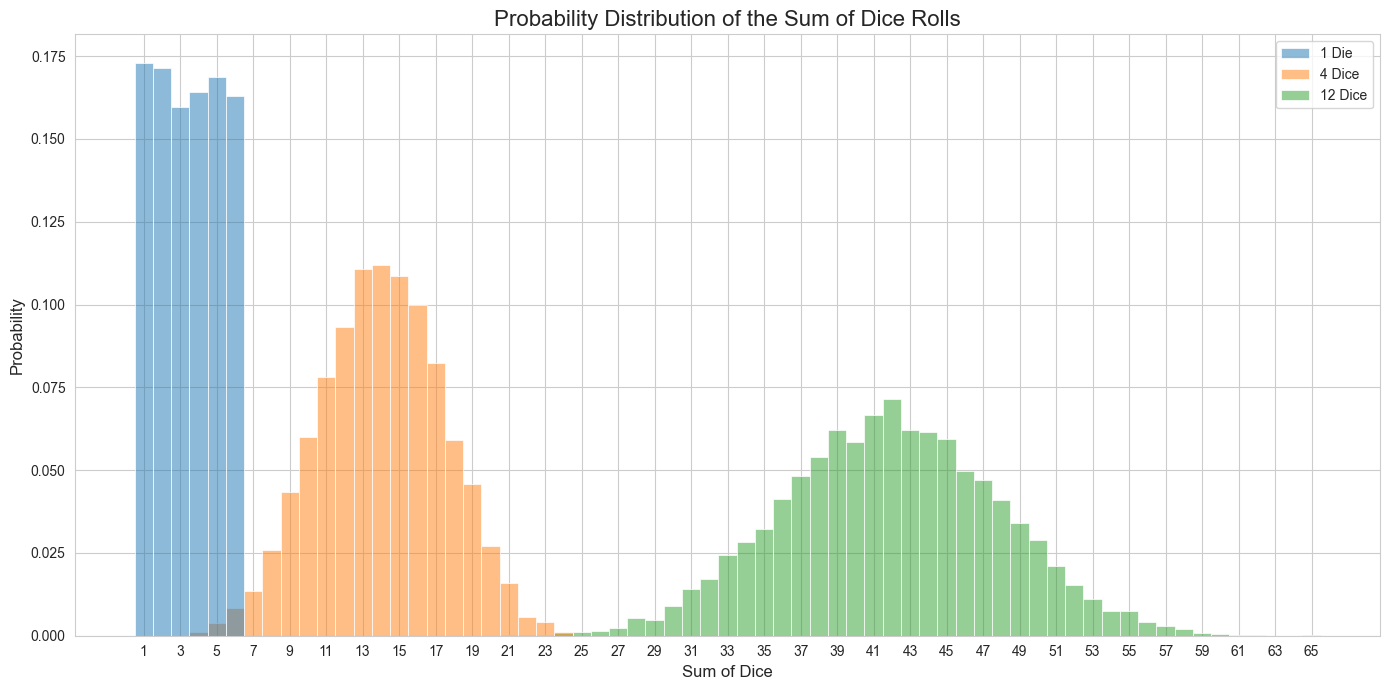

In [5]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(14, 7))

sns.histplot(
    data=df_sums,
    stat="probability",
    common_norm=False,
    discrete=True,
    linewidth=0.5,
    ax=ax
)

ax.set_title('Probability Distribution of the Sum of Dice Rolls', fontsize=16)
ax.set_xlabel('Sum of Dice', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)

max_sum = df_sums.max().max()
ax.set_xticks(np.arange(1, max_sum + 2, 2))

plt.tight_layout()
plt.show()

## 6. Faceted View — One Panel per Experiment

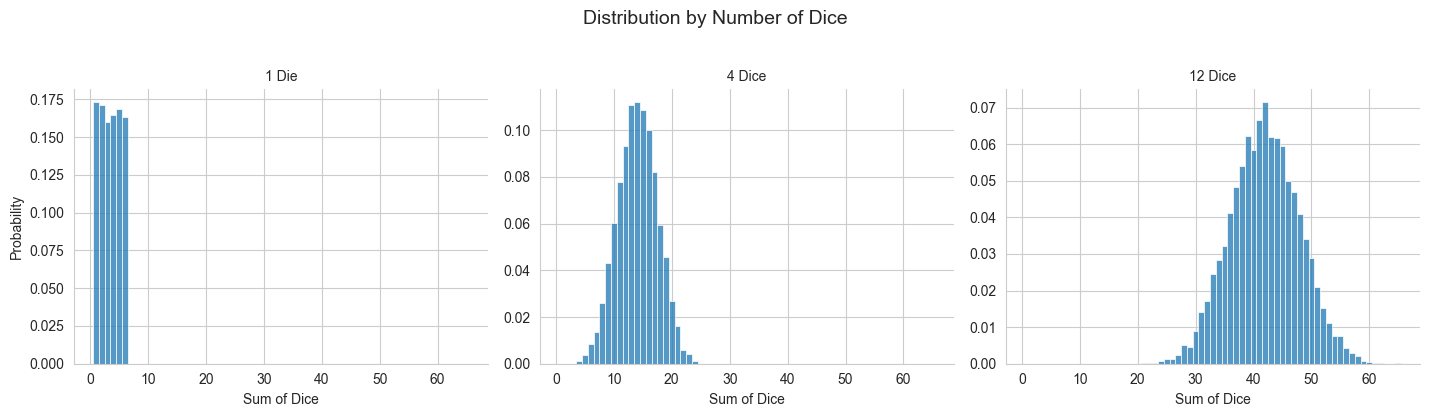

In [6]:
df_long = df_sums.melt(var_name='Experiment', value_name='Sum')

g = sns.FacetGrid(df_long, col='Experiment', sharey=False, height=4, aspect=1.2)
g.map(sns.histplot, 'Sum', stat='probability', discrete=True, linewidth=0.5)
g.set_axis_labels('Sum of Dice', 'Probability')
g.set_titles('{col_name}')
g.figure.suptitle('Distribution by Number of Dice', y=1.03, fontsize=14)
plt.tight_layout()
plt.show()